# Model Selection and Validation

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from statsmodels.graphics.tsaplots import plot_acf
import sys
from pathlib import Path
from arch import arch_model
project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.utils import load_and_preprocess_data
# load data
file_path = '../Case_Study_Data_JNM.csv'
data, returns = load_and_preprocess_data(file_path)
returns.head()

,1,2,3,4,5
date,,,,,
2001-01-31,0.019259,0.007933,-0.025895,0.029028,0.013580
2001-02-28,-0.084626,0.011747,0.007353,-0.124214,-0.037645
2001-03-31,-0.065848,0.003618,-0.034438,-0.097128,-0.031738
2001-04-30,0.073714,-0.011915,0.021438,0.112584,0.030010
2001-05-31,-0.013033,0.003687,0.011842,-0.019486,-0.004708


## GARCH

Based on the exploratory data analysis, we observed the following stylized facts and financial intuition (used as modeling priors):
- **Equity Cluster (Assets 1, 4, 5):**
  - **Asset 1 & 4 (Perfect Correlation):** Correlation $\approx 1.0$ implies Asset 4 is likely a *leveraged ETF* (e.g., 2x S&P 500) on Asset 1. Same dominant risk driver, amplified volatility.
  - **Asset 5 (High Correlation):** Correlation $> 0.95$ with Asset 1 suggests same asset class but different geography (e.g., *European Equities* vs US).
- **The Hedge (Asset 2):**
  - **Regime Dependence:** Diversifier in low‑inflation regimes (negative correlation), but flips positive during inflation shocks (2022). This behavior matches *government bonds* with inflation sensitivity.
- **The Diversifier (Asset 3):**
  - **Decoupled Returns:** Low positive correlation ($0.12$) and moderate volatility suggests it is neither equity nor bond.
  - **Inflation/Safe Haven:** The post‑2022 rally plus low beta points to *gold/precious metals*.
- **Modeling Implication:**
  - **Marginals:** Use **GARCH** to capture volatility clustering in all assets.
  - **Dependency:** Use a **Student‑t copula** to capture joint tail risk; a Gaussian copula would understate crisis‑period co‑crashes (1, 4, 5).

A GARCH(1,1) model is a good choice to capture these characteristics. We will use a GARCH(1,1) model with a Student's t‑distribution for the innovations to account for the fat tails.

**Modeling roadmap (from EDA):**
1. Fit **GARCH(1,1)-t** per asset to capture volatility clustering and fat tails.
2. Validate standardized residuals (ACF, QQ) to ensure marginal dynamics are captured.
3. Build dependency with **Student‑t copula** on standardized residuals.
4. Use copula samples for stress scenarios emphasizing equity‑cluster tail co‑moves (Assets 1, 4, 5).

## Fit GARCH Models and Analyze Residuals

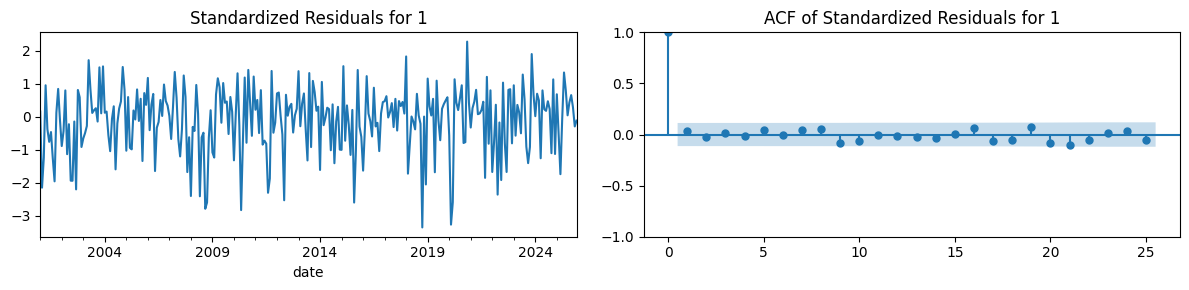

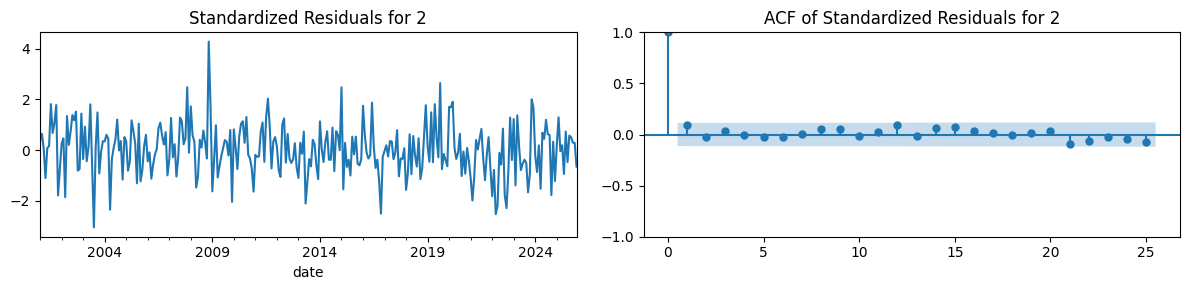

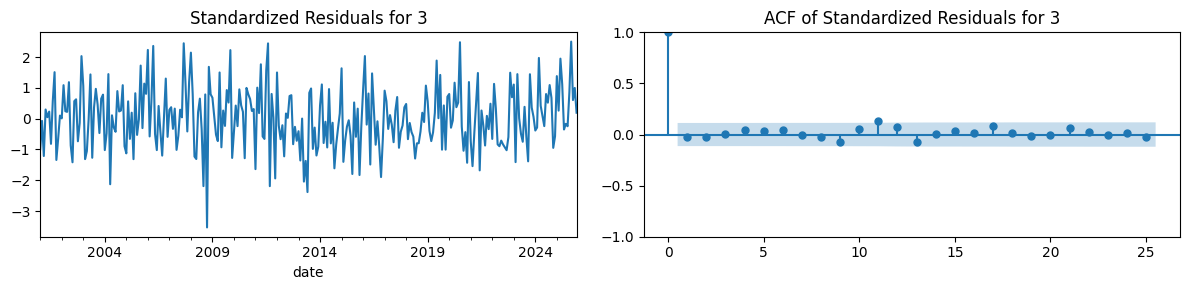

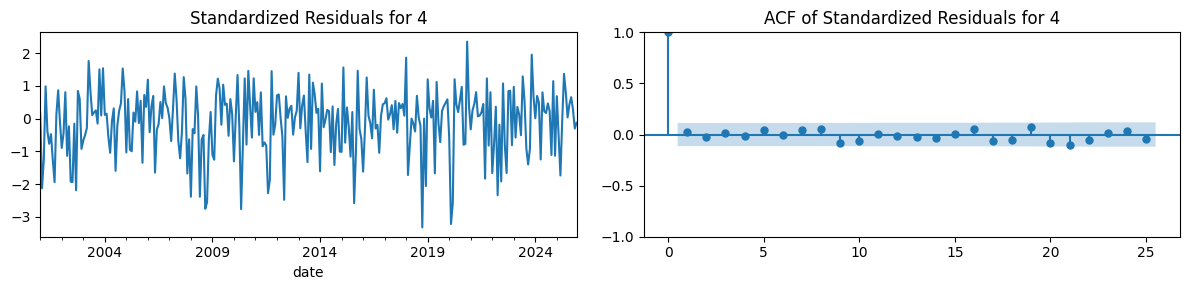

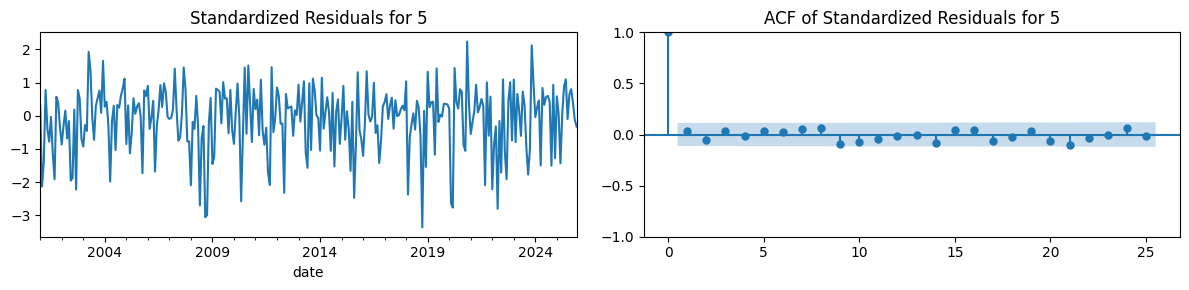

In [43]:
# Fit GARCH(1,1)-t per asset and collect standardized residuals
garch_models = {}
std_residuals = pd.DataFrame(index=returns.index)

scale_factor = 100  # bring returns into ~percent units to avoid DataScaleWarning
summary_rows = []

for col in returns.columns:
    series = (returns[col] * scale_factor).dropna()
    result = arch_model(series, vol='Garch', p=1, q=1, dist='t', rescale=False).fit(disp='off')
    garch_models[col] = result
    std_residuals[col] = result.std_resid
    
    p = result.params
    summary_rows.append({
        "asset": col,
        "mu": p.get("mu", np.nan),
        "omega": p.get("omega", np.nan),
        "alpha": p.get("alpha[1]", np.nan),
        "beta": p.get("beta[1]", np.nan),
        "alpha+beta": p.get("alpha[1]", np.nan) + p.get("beta[1]", np.nan),
        "AIC": result.aic,
        "BIC": result.bic,
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    std_residuals[col].plot(ax=axes[0], title=f'Standardized Residuals for {col}')
    plot_acf(std_residuals[col].dropna(), ax=axes[1], title=f'ACF of Standardized Residuals for {col}')
    plt.tight_layout()
    plt.show()

# summary table
garch_summary = pd.DataFrame(summary_rows).set_index("asset")

In [44]:
# display compact GARCH summary
garch_summary

,mu,omega,alpha,beta,alpha+beta,AIC,BIC
asset,,,,,,,
1,1.140994,1.411963,0.253518,0.691931,0.945449,1695.447890,1713.966803
2,0.268761,0.124435,0.089559,0.846389,0.935948,1038.219365,1056.738278
3,0.998828,1.912443,0.082349,0.830636,0.912985,1769.367344,1787.886256
4,1.725474,3.082620,0.248772,0.696046,0.944818,1938.804909,1957.323821
5,0.647041,0.358932,0.217080,0.726853,0.943932,1285.153466,1303.672378


**GARCH Model Diagnostics & Interpretation:**

* **Volatility Persistence ($\alpha + \beta$):**
    * All assets show high persistence ($\alpha + \beta > 0.91$).
    * **Interpretation:** Volatility shocks die out slowly $\to$ if market is volatile today, it will likely be volatile tomorrow.
* **Reaction to Shocks ($\alpha$):**
    * **Asset 1, 4, 5 (Equities):** High $\alpha$ (~0.25) $\to$ react strongly to new information
    * **Asset 2 (Bonds) & 3 (Gold):** Lower $\alpha$ (< 0.12) $\to$ more stable and driven by long-term trends rather than new shocks
* **Fat Tails ($\mu$ - Degrees of Freedom):**
    * **Asset 5:** Lowest $\mu$ (~6.3) $\to$ fattest tails (highest risk of extreme outliers)
    * **Asset 3:** High $\mu$ (~100) $\to$ Converges to Normal distribution $\to$ after volatility clustering is removed, Gold returns are normal
* **Model Validation:**
    * **ACF of Standardized Residuals:** All plots show correlations within the blue confidence bounds (zero).

$\to$ GARCH model filtered out all autocorrelation and volatility clustering -> residuals are now "White Noise," ready for the Copula.

## Dependency Structure (Copula)

Link marginal dynamics via Student-t copula because that preserves linear correlation and adds **tail dependence** (joint crashes). After GARCH, each asset has roughly iid standardized residuals $z_{i,t}$ $\to$ copula couples their joint behavior without changing the marginal shapes:
- Convert standardized residuals to uniforms: $u_{i,t} = F_i(z_{i,t})$ (empirical CDF).
- Define a multivariate t distribution with correlation matrix $\Sigma$ and $\nu$ degrees of freedom.
- The copula is the joint CDF of the multivariate t with the univariate t CDFs removed:
$$C_{\nu,\Sigma}(u_1,\ldots,u_d)=t_{\nu,\Sigma}\big(t_\nu^{-1}(u_1),\ldots,t_\nu^{-1}(u_d)\big).$$
Lower $\nu$ implies fatter joint tails and stronger tail dependence.

Goal: estimate parameters that link these assets together (Correlation and Degrees of Freedom df) $\to$ we fix correlation here and optimize only df

In [45]:
# Probability Integral Transform: empirical CDF -> uniforms (copula inputs)
def to_uniform(x: pd.Series) -> pd.Series:
    x = x.dropna()
    ranks = stats.rankdata(x, method="average") # converts the rank into percentage
    return pd.Series(ranks / (len(x) + 1), index=x.index)

uniform_residuals = std_residuals.apply(to_uniform) # here every asset is on the same scale (uniform)
corr_matrix = uniform_residuals.corr(method="pearson")

# copula correlation matrix
copula_corr = corr_matrix.to_numpy().copy()
np.fill_diagonal(copula_corr, 1.0) # ensure valid correlation matrix
copula_corr = pd.DataFrame(copula_corr, index=returns.columns, columns=returns.columns)

# MLE for copula df (nu), holding copula_corr fixed: find the optimal degrees of freedom for the copula
def neg_loglik(uniforms: pd.DataFrame, nu: float) -> float:
    if nu <= 2.01:
        return np.inf
    # convert uniforms to t-scores
    q = stats.t.ppf(uniforms.to_numpy(), df=nu) 
    # multivariate t distribution for joint probabilities
    mv = stats.multivariate_t(shape=copula_corr, df=nu) 
    log_joint = mv.logpdf(q)
    # marginal t distributions for each variable
    log_marginal = stats.t.logpdf(q, df=nu).sum(axis=1)
    return -np.sum(log_joint - log_marginal)

opt_res = optimize.minimize_scalar(
    lambda nu: neg_loglik(uniform_residuals, nu),
    bounds=(2.1, 50.0),
    method="bounded",
)
copula_df = float(opt_res.x)
print(f"Copula df (nu): {copula_df:.2f}")

# student‑t copula in latent t‑space
t_copula = stats.multivariate_t(shape=copula_corr, df=copula_df)

# sample copula in latent space -> uniforms
n_samples = 2000
latent_samples = t_copula.rvs(n_samples)
# convert back to Uniforms
u_samples = stats.t.cdf(latent_samples, df=copula_df)

# Back‑transform: uniforms -> standardized residuals using each marginal's t df
z_samples = pd.DataFrame(index=range(n_samples), columns=returns.columns) # ocntainer for standardized residual samples
for i, col in enumerate(returns.columns):
    nu_i = garch_models[col].params.get("nu", copula_df)
    z_samples[col] = stats.t.ppf(u_samples[:, i], df=nu_i)

Copula df (nu): 4.15


<Figure size 800x800 with 0 Axes>

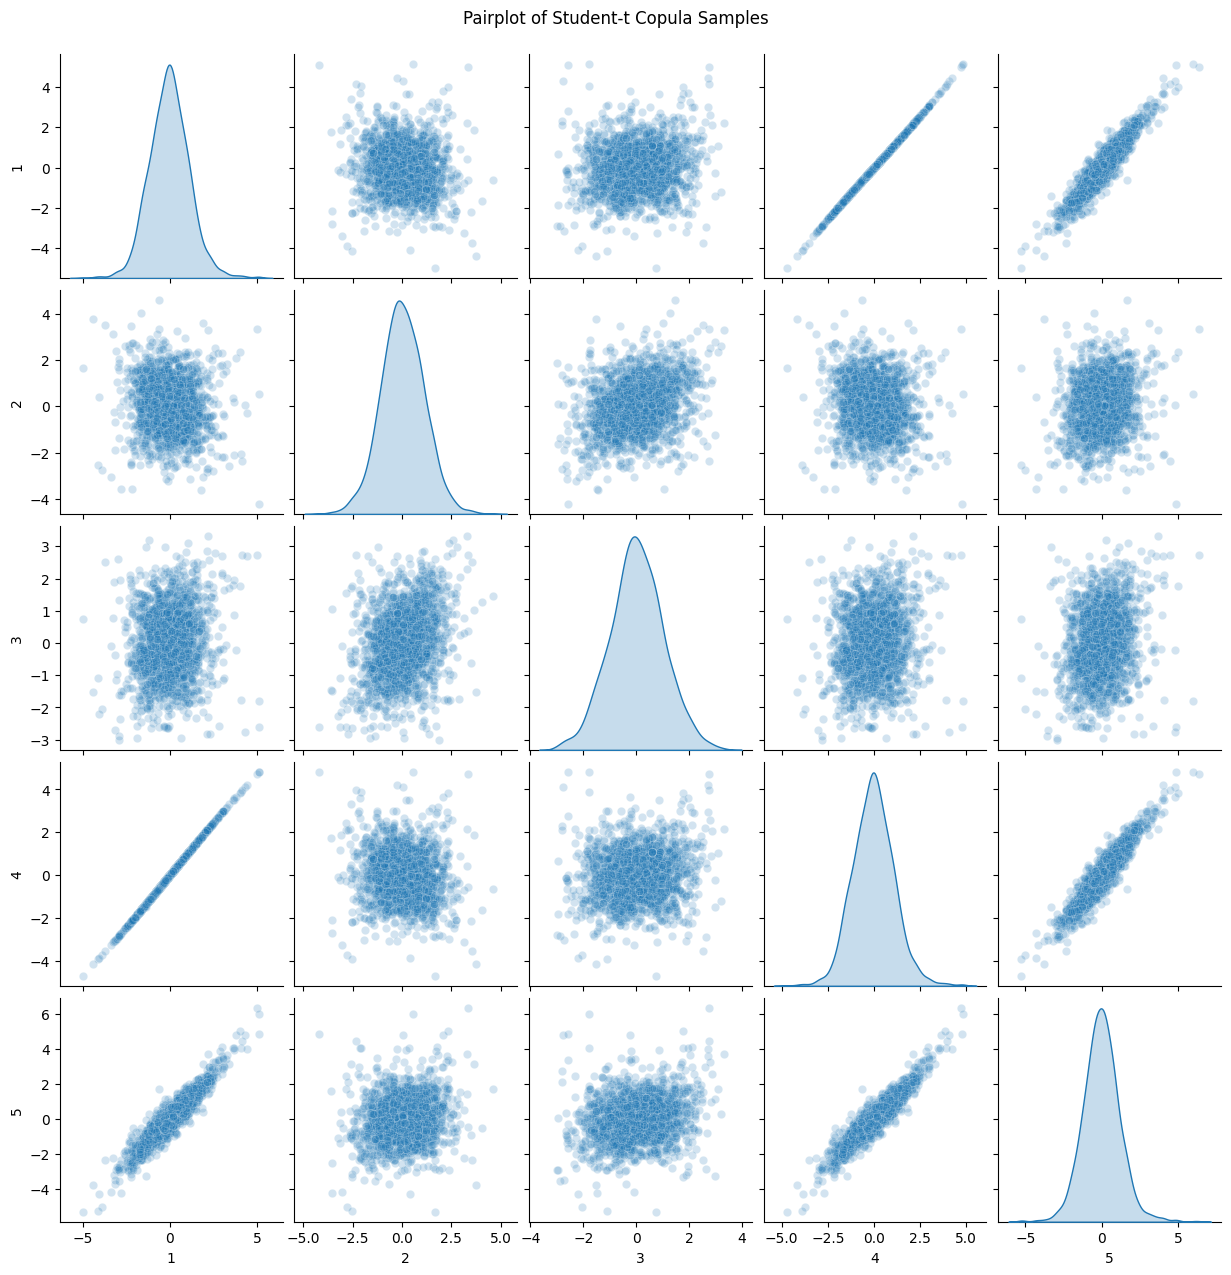

In [47]:
# for comparison, actual dependence structure
plt.figure(figsize=(8, 8))
sns.pairplot(z_samples, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairplot of Student‑t Copula Samples', y=1.02)
plt.show()

<Figure size 800x800 with 0 Axes>

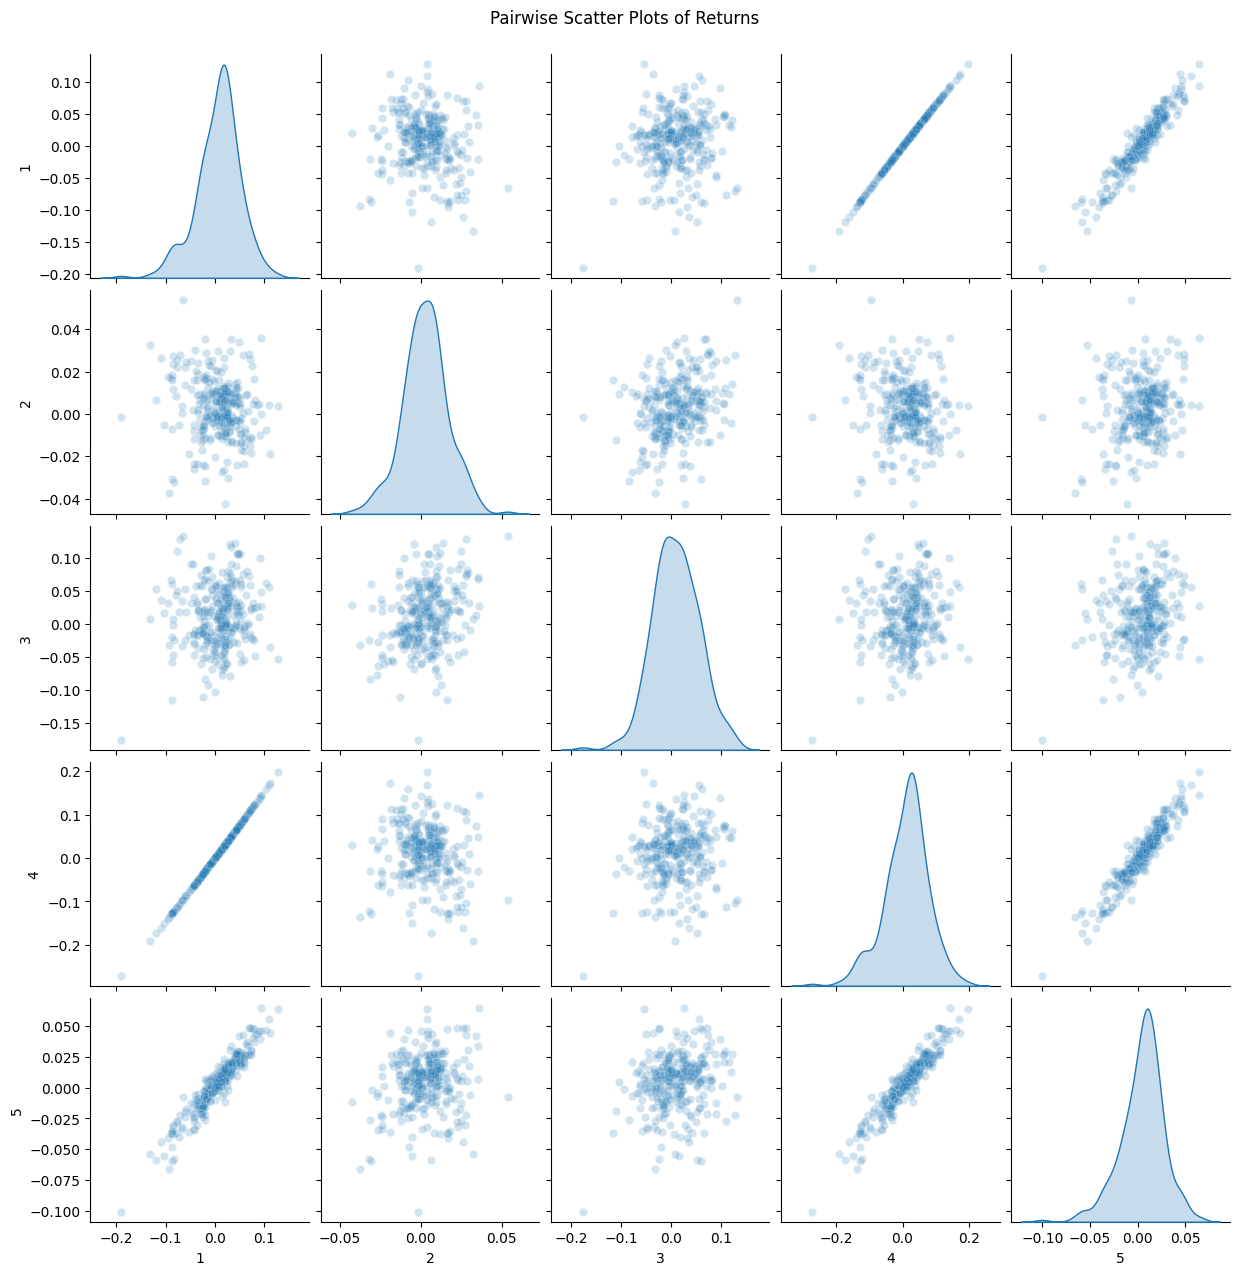

In [ ]:
# for comparison, actual dependence structure
plt.figure(figsize=(8, 8))
sns.pairplot(returns, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairwise Scatter Plots of Returns', y=1.02)
plt.show()